<a href="https://colab.research.google.com/github/laramutair/Car-Insurance-Claim-Prediction/blob/main/Project_4_Part_1_(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
def plot_importance(importances, top_n=None,  figsize=(8,6)):
    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Importance',
            ylabel='Feature Names',
            title=title)
    ## return ax in case want to continue to update/modify figure
    return ax

In [2]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [3]:
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [4]:
def plot_categorical_vs_target(df, x, y, figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None, target_type='class'):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)
  # REGRESSION-TARGET PLOT
  if target_type=='reg': #Added if statement here
    # Barplot
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                linewidth=1, edgecolor='black', errorbar=None)
    # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                  order=order, hue_order=order, legend=False,
                  edgecolor='white', linewidth=0.5,
                  size=3,zorder=0)
  # CLASSIFICATION-TARGET PLOT # This is the new code for the classification task
  elif target_type=='class':
    ax = sns.histplot(data=temp_df, hue=y, x=x, stat='percent',  multiple='fill')
  # Rotate xlabels
  ax.set_xticks(ax.get_xticks()) # Added this to prevent a bug
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

In [5]:
def plot_numeric_vs_target(df, x, y, figsize=(6,4),
                           target_type='class', estimator='mean',
                           errorbar='ci',sorted=False,ascending=False,
                           **kwargs): # kwargs for sns.regplot

  nulls = df[[x,y]].isna().sum()
  if nulls.sum()>0:
    print(f"- Excluding {nulls.sum()} NaN's")
    # print(nulls)
    temp_df = df.dropna(subset=[x,y,])
  else:
    temp_df = df
  # Create the figure
  fig, ax = plt.subplots(figsize=figsize)

  # REGRESSION-TARGET PLOT
  if 'reg' in target_type:
    # Calculate the correlation
    corr = df[[x,y]].corr().round(2)
    r = corr.loc[x,y]
    # Plot the data
    scatter_kws={'ec':'white','lw':1,'alpha':0.8}
    sns.regplot(data=temp_df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
    ## Add the title with the correlation
    ax.set_title(f"{x} vs. {y} (r = {r})")

  # CLASSIFICATION-TARGET PLOT
  elif 'class' in target_type:

    # Sort the groups by median/mean
    if sorted == True:

      if estimator == 'median':
        group_vals = temp_df.groupby(y)[x].median()
      elif estimator =='mean':
        group_vals = temp_df.groupby(y)[x].mean()

      ## Sort values
      group_vals = group_vals.sort_values(ascending=ascending)
      order = group_vals.index

    else:
      # Set order to None if not calcualted
      order = None


    # Left Subplot (barplot)
    sns.barplot(data=temp_df, x=y, y=x, order=order,  estimator=estimator,
                errorbar=errorbar, ax=ax, **kwargs)

    # Add title
    ax.set_title(f"{x} vs. {y}")

    # rotate xaxis labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


  # Final Adjustments & return
  fig.tight_layout()
  fig.show()
  return fig, ax

## Import and LOad Data

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,  confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import silhouette_score


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sagnik1511/car-insurance-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-insurance-data' dataset.
Path to dataset files: /kaggle/input/car-insurance-data


In [8]:
df = pd.read_csv(path + "/Car_Insurance_Claim.csv")
df.head()

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATIONS  10000 non-null  

In [10]:
df.describe()

,ID,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
count,10000.000000,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,290030.768758,0.137688,0.459578,0.500022,0.463008,18915.613855,2818.434528,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


In [11]:
df.describe(include="object")

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,VEHICLE_YEAR,VEHICLE_TYPE
count,10000,10000,10000,10000,10000,10000,10000,10000
unique,4,2,2,4,3,4,2,2
top,26-39,female,majority,0-9y,high school,upper class,before 2015,sedan
freq,3063,5010,9012,3530,4157,4336,6967,9523


## Clean Data

### Missing value

In [12]:
df.isna().sum()

,0
ID,0
AGE,0
GENDER,0
RACE,0
DRIVING_EXPERIENCE,0
EDUCATION,0
INCOME,0
CREDIT_SCORE,982
VEHICLE_OWNERSHIP,0
VEHICLE_YEAR,0


### Drop The ID Column

In [13]:
df = df.drop(columns='ID')

### Duplicates

In [14]:
df.duplicated().sum()

np.int64(12)

In [15]:
df = df.drop_duplicates(keep='first')

In [16]:
df.duplicated().sum()

np.int64(0)

### Check and Fix Data type

In [17]:
obj_cols =df.astype('object').columns
obj_cols

Index(['AGE', 'GENDER', 'RACE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME',
       'CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'VEHICLE_YEAR', 'MARRIED',
       'CHILDREN', 'POSTAL_CODE', 'ANNUAL_MILEAGE', 'VEHICLE_TYPE',
       'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'OUTCOME'],
      dtype='object')

In [18]:
for col in obj_cols:
    print(f"{col}: {df[col].unique()}")
    print('------------------------------------------------')


AGE: ['65+' '16-25' '26-39' '40-64']
------------------------------------------------
GENDER: ['female' 'male']
------------------------------------------------
RACE: ['majority' 'minority']
------------------------------------------------
DRIVING_EXPERIENCE: ['0-9y' '10-19y' '20-29y' '30y+']
------------------------------------------------
EDUCATION: ['high school' 'none' 'university']
------------------------------------------------
INCOME: ['upper class' 'poverty' 'working class' 'middle class']
------------------------------------------------
CREDIT_SCORE: [0.62902731 0.35775712 0.49314579 ... 0.47094023 0.36418478 0.43522478]
------------------------------------------------
VEHICLE_OWNERSHIP: [1. 0.]
------------------------------------------------
VEHICLE_YEAR: ['after 2015' 'before 2015']
------------------------------------------------
MARRIED: [0. 1.]
------------------------------------------------
CHILDREN: [1. 0.]
------------------------------------------------
POSTAL_CODE

In [19]:
for col in obj_cols:
    print(f"{col}: {df[col].value_counts()}")
    print('------------------------------------------------')

AGE: AGE
26-39    3062
40-64    2931
16-25    2005
65+      1990
Name: count, dtype: int64
------------------------------------------------
GENDER: GENDER
female    5003
male      4985
Name: count, dtype: int64
------------------------------------------------
RACE: RACE
majority    9000
minority     988
Name: count, dtype: int64
------------------------------------------------
DRIVING_EXPERIENCE: DRIVING_EXPERIENCE
0-9y      3519
10-19y    3298
20-29y    2119
30y+      1052
Name: count, dtype: int64
------------------------------------------------
EDUCATION: EDUCATION
high school    4151
university     3927
none           1910
Name: count, dtype: int64
------------------------------------------------
INCOME: INCOME
upper class      4335
middle class     2138
poverty          1804
working class    1711
Name: count, dtype: int64
------------------------------------------------
CREDIT_SCORE: CREDIT_SCORE
0.435225    1
0.629027    1
0.357757    1
0.493146    1
0.206013    1
           ..
0

In [20]:
df['CREDIT_SCORE'] = df['CREDIT_SCORE'].astype(float)

In [21]:
df['ANNUAL_MILEAGE']=df['ANNUAL_MILEAGE'].astype(float)

### Check for Inconsistent Data

In [22]:
cat_cols = df.select_dtypes(include='object').columns

In [23]:
for col in cat_cols:
    print(f'\n{col}: {df[col].unique()}')


AGE: ['65+' '16-25' '26-39' '40-64']

GENDER: ['female' 'male']

RACE: ['majority' 'minority']

DRIVING_EXPERIENCE: ['0-9y' '10-19y' '20-29y' '30y+']

EDUCATION: ['high school' 'none' 'university']

INCOME: ['upper class' 'poverty' 'working class' 'middle class']

VEHICLE_YEAR: ['after 2015' 'before 2015']

VEHICLE_TYPE: ['sedan' 'sports car']


In [24]:
for col in cat_cols:
    df[col] = df[col].str.strip().str.upper()

print('Categorical values standardized (stripped + uppercased)')

Categorical values standardized (stripped + uppercased)


## Check Data balance

In [25]:
df['OUTCOME'].value_counts(normalize=True)

,proportion
OUTCOME,
0.0,0.687225
1.0,0.312775


## EDA

### Histogram

array([[<Axes: title={'center': 'CREDIT_SCORE'}>,
        <Axes: title={'center': 'VEHICLE_OWNERSHIP'}>,
        <Axes: title={'center': 'MARRIED'}>],
       [<Axes: title={'center': 'CHILDREN'}>,
        <Axes: title={'center': 'POSTAL_CODE'}>,
        <Axes: title={'center': 'ANNUAL_MILEAGE'}>],
       [<Axes: title={'center': 'SPEEDING_VIOLATIONS'}>,
        <Axes: title={'center': 'DUIS'}>,
        <Axes: title={'center': 'PAST_ACCIDENTS'}>],
       [<Axes: title={'center': 'OUTCOME'}>, <Axes: >, <Axes: >]],
      dtype=object)

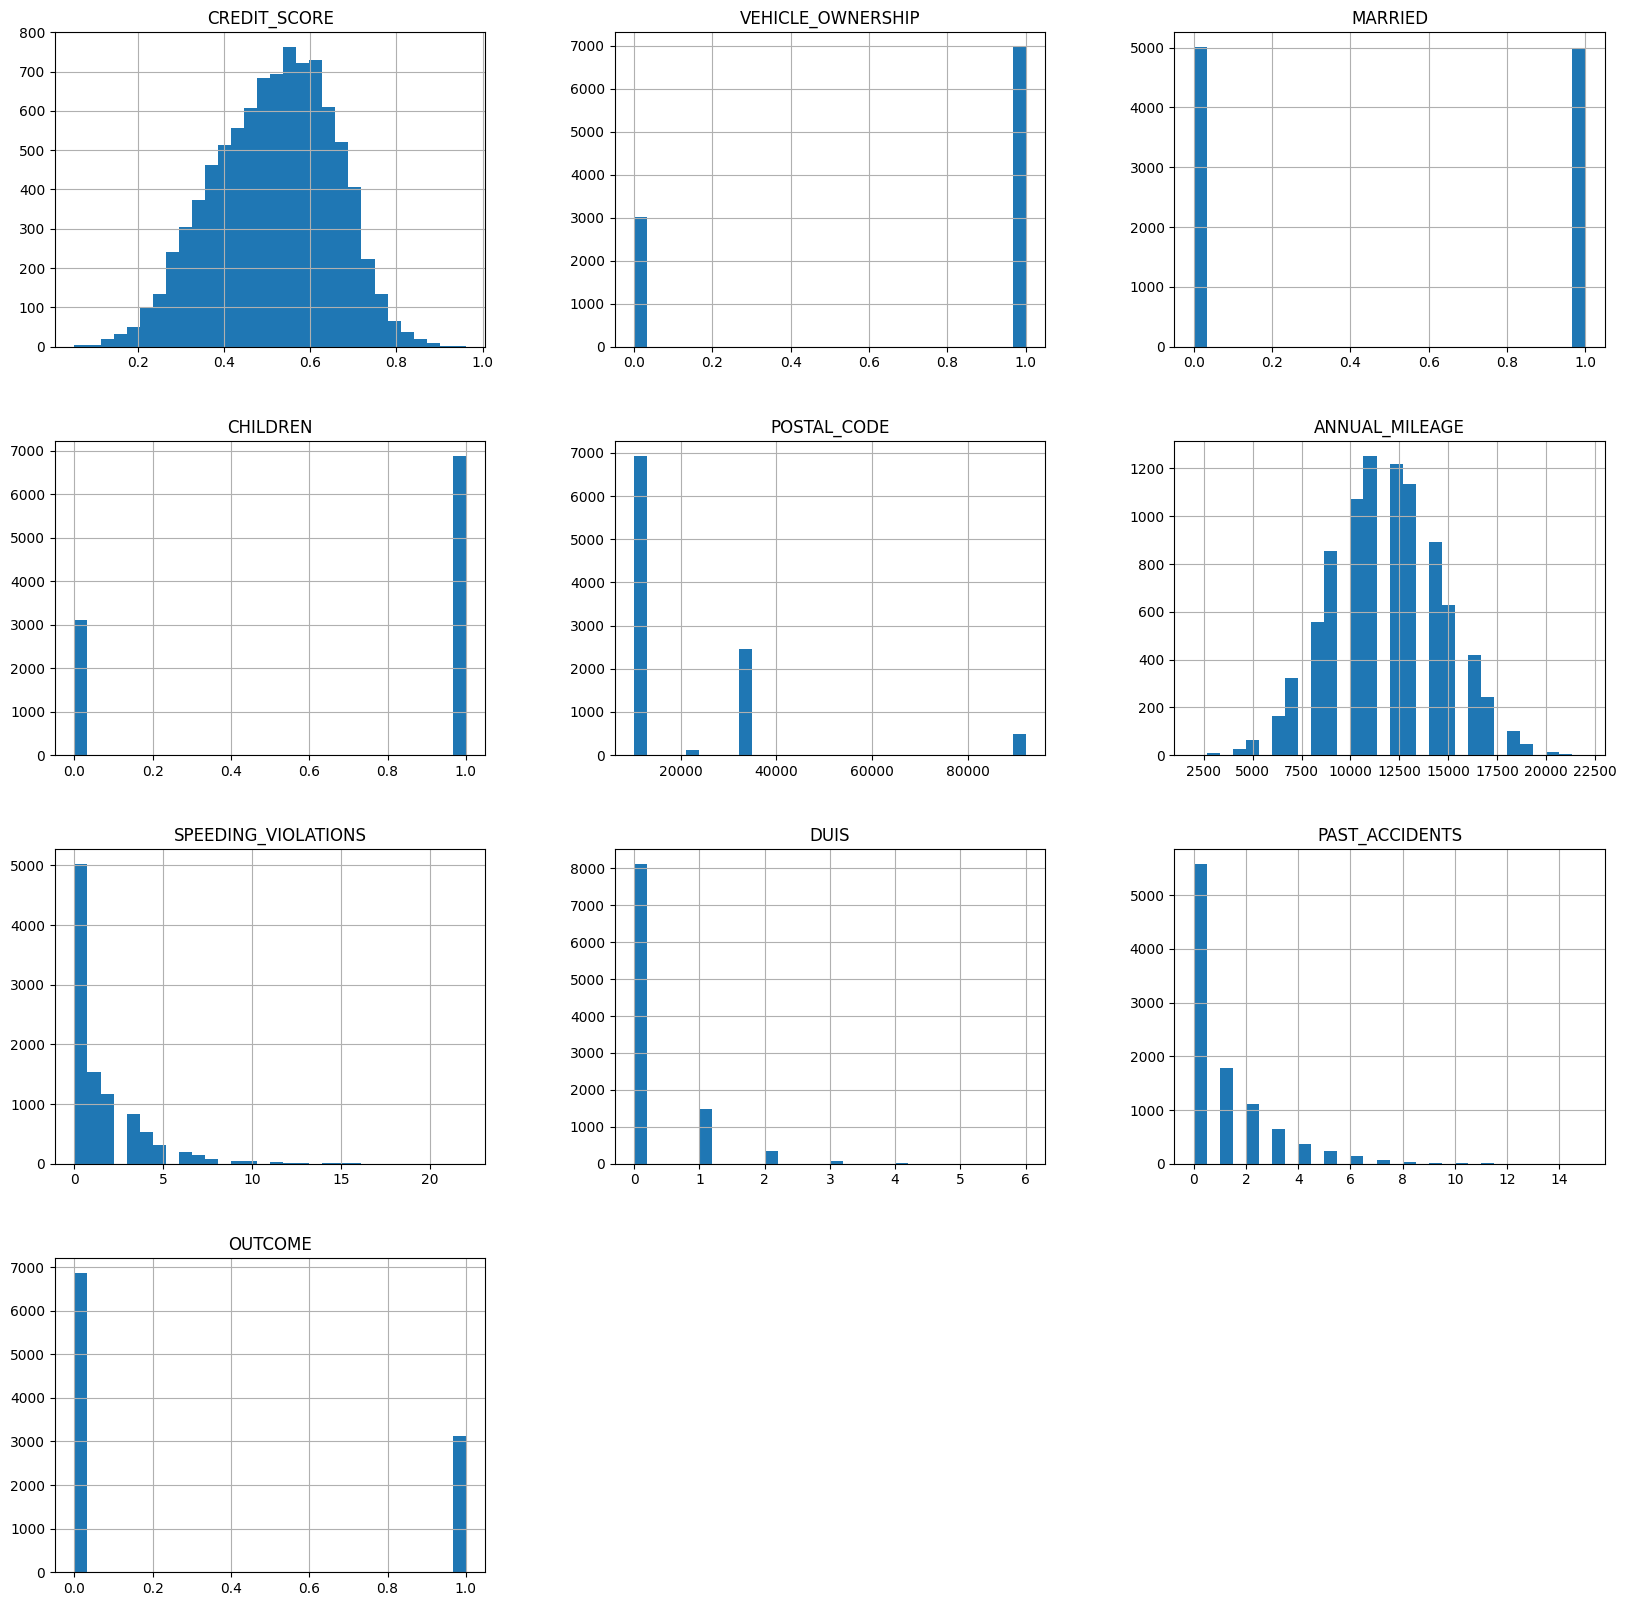

In [26]:
df.hist(bins=30, figsize=(20,20))

### Outcome VS Vechicle Type

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'VEHICLE_TYPE vs. OUTCOME'}, xlabel='VEHICLE_TYPE', ylabel='Percent'>)

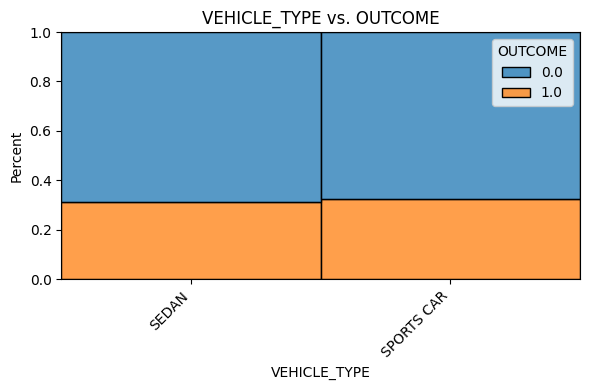

In [27]:
plot_categorical_vs_target(df, x='VEHICLE_TYPE', y='OUTCOME', figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None)

### OutCome Vs Age

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'AGE vs. OUTCOME'}, xlabel='AGE', ylabel='Percent'>)

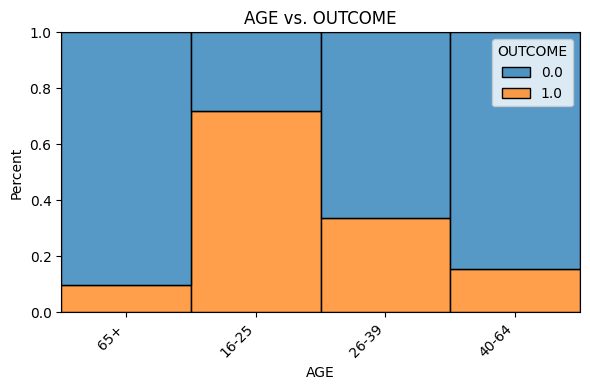

In [28]:
plot_categorical_vs_target(df, x='AGE', y='OUTCOME', figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None)

### OutCome VS Credit Score

- Excluding 970 NaN's


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'CREDIT_SCORE vs. OUTCOME'}, xlabel='OUTCOME', ylabel='CREDIT_SCORE'>)

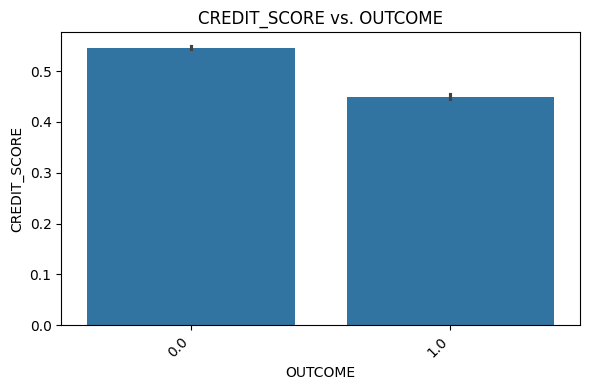

In [29]:
plot_numeric_vs_target(df, x='CREDIT_SCORE', y='OUTCOME', figsize=(6,4),
                       target_type='class', estimator='mean',
                       errorbar='ci',sorted=False,ascending=False)

<Axes: >

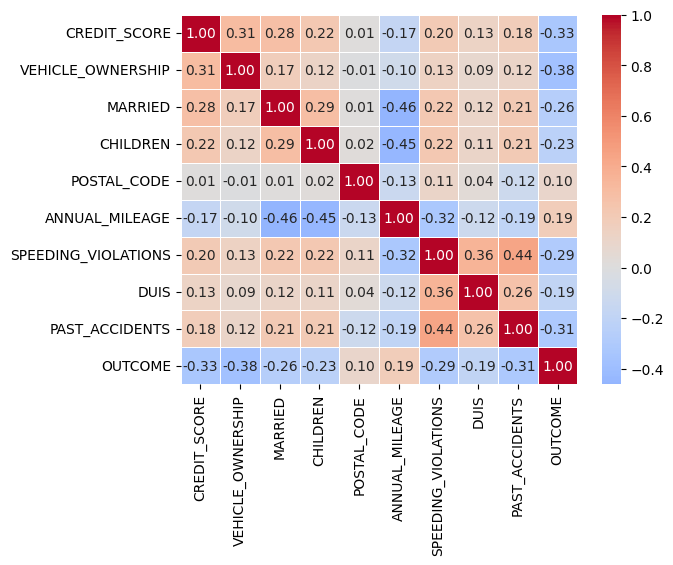

In [30]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0,  linewidths=0.5)


## Preprocess

In [31]:
numeric_col =['CREDIT_SCORE','ANNUAL_MILEAGE','SPEEDING_VIOLATIONS','DUIS','PAST_ACCIDENTS']
ordinal_col = ['AGE','DRIVING_EXPERIENCE','EDUCATION','INCOME','VEHICLE_YEAR']
cat_col = ['GENDER','RACE','VEHICLE_TYPE','VEHICLE_OWNERSHIP','MARRIED','CHILDREN','POSTAL_CODE']

### Procee the numeric cols

In [32]:
df[numeric_col].isna().sum()

,0
CREDIT_SCORE,970
ANNUAL_MILEAGE,954
SPEEDING_VIOLATIONS,0
DUIS,0
PAST_ACCIDENTS,0


In [33]:
X = df.drop(columns='OUTCOME')
y = df['OUTCOME']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
impute  = SimpleImputer(strategy='median')
scaled = StandardScaler()
num_pip = make_pipeline(impute, scaled)
num_tuple=('numeric', num_pip, numeric_col)
num_pip

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

### Cat Columns

In [36]:
df[cat_col].isna().sum()

,0
GENDER,0
RACE,0
VEHICLE_TYPE,0
VEHICLE_OWNERSHIP,0
MARRIED,0
CHILDREN,0
POSTAL_CODE,0


In [37]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_pip = make_pipeline(encoder)
cat_tuple = ('categorical', cat_pip, cat_col)

### Ordianl Columns

In [38]:
df[ordinal_col].isna().sum()

,0
AGE,0
DRIVING_EXPERIENCE,0
EDUCATION,0
INCOME,0
VEHICLE_YEAR,0


In [39]:
ord_encoder = OrdinalEncoder(categories=[
    ['16-25', '26-39', '40-64', '65+'],          # AGE
    ['0-9Y', '10-19Y', '20-29Y', '30Y+'],         # DRIVING_EXPERIENCE
    ['NONE', 'HIGH SCHOOL', 'UNIVERSITY'],         # EDUCATION
    ['POVERTY', 'WORKING CLASS', 'MIDDLE CLASS', 'UPPER CLASS'],  # INCOME
    ['BEFORE 2015', 'AFTER 2015']                  # VEHICLE_YEAR
])
scaler = StandardScaler()
ord_pip = make_pipeline(ord_encoder, scaler)
ord_tuple = ('ordinal', ord_pip, ordinal_col)

In [40]:
preprocessor = ColumnTransformer([num_tuple, cat_tuple, ord_tuple],
                                  verbose_feature_names_out=False)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)   # transform فقط!

print(f"Train shape: {X_train_prep.shape}")
print(f"Test shape:  {X_test_prep.shape}")

Train shape: (7990, 26)
Test shape:  (1998, 26)


## Model by Default Logistic Regression

In [41]:
lr = LogisticRegression(random_state=42, max_iter=1000)

In [42]:
lr.fit(X_train_prep, y_train)

LogisticRegression(max_iter=1000, random_state=42)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89      5497
         1.0       0.78      0.73      0.75      2493

    accuracy                           0.85      7990
   macro avg       0.83      0.82      0.82      7990
weighted avg       0.85      0.85      0.85      7990



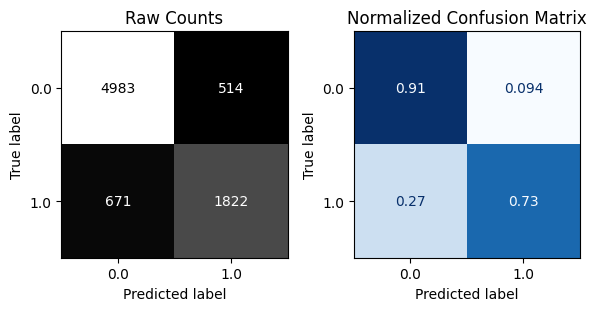


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.90      1367
         1.0       0.79      0.74      0.77       631

    accuracy                           0.86      1998
   macro avg       0.84      0.83      0.83      1998
weighted avg       0.86      0.86      0.86      1998



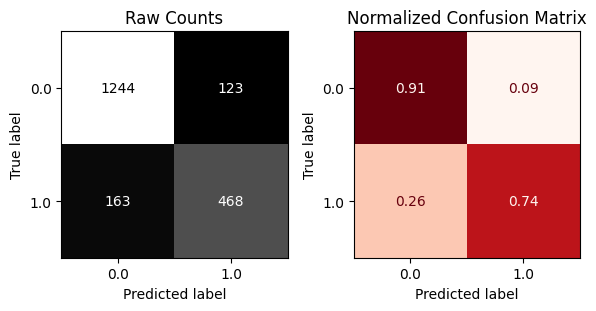

In [43]:
evaluate_classification(lr, X_train_prep, y_train,  X_test_prep, y_test)

## Permutation Importance

In [44]:
perm_result = permutation_importance(
    lr,
    X_test_prep,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)


In [45]:
feature_names = preprocessor.get_feature_names_out()

perm_df = pd.DataFrame({
    'Feature'         : feature_names,
    'Importance Mean' : perm_result.importances_mean,
    'Importance Std'  : perm_result.importances_std
}).sort_values('Importance Mean', ascending=False)

In [46]:
#Show top 10
top10 = perm_df.head(10).reset_index(drop=True)
top10

,Feature,Importance Mean,Importance Std
0,DRIVING_EXPERIENCE,0.140340,0.007181
1,POSTAL_CODE_10238,0.059159,0.005044
2,VEHICLE_YEAR,0.038939,0.004015
3,POSTAL_CODE_32765,0.021972,0.003015
4,VEHICLE_OWNERSHIP_0.0,0.012863,0.003290
5,VEHICLE_OWNERSHIP_1.0,0.011261,0.003448
6,ANNUAL_MILEAGE,0.009660,0.002936
7,GENDER_MALE,0.008458,0.003442
8,POSTAL_CODE_92101,0.008108,0.001159
9,GENDER_FEMALE,0.006356,0.002961


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'DRIVING_EXPERIENCE vs. OUTCOME'}, xlabel='DRIVING_EXPERIENCE', ylabel='Percent'>)

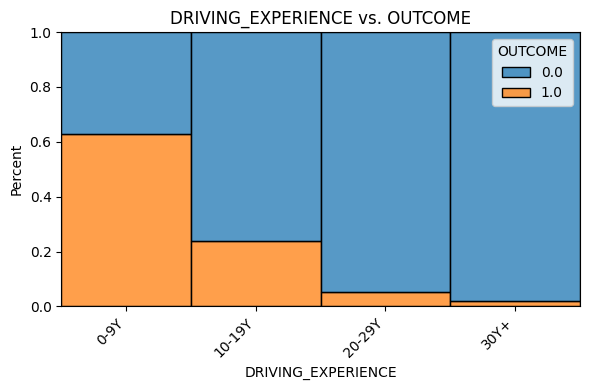

In [47]:
plot_categorical_vs_target(df, x='DRIVING_EXPERIENCE', y='OUTCOME', figsize=(6,4),
                       target_type='class')

The plot shows:
   - As driving experience increases, the claim rate drops dramatically. Drivers with 0–9 years of experience file claims at a rate of approximately 62%, while drivers with 30+ years of experience have a claim rate close to 0%. This makes strong business sense, experienced drivers have developed better road awareness and decision-making skills over time. Insurance companies can confidently use driving experience as one of the most reliable indicators of customer risk level.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'VEHICLE_OWNERSHIP vs. OUTCOME'}, xlabel='VEHICLE_OWNERSHIP', ylabel='Percent'>)

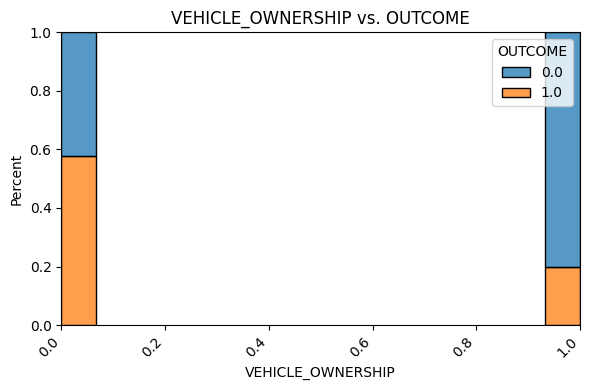

In [48]:
plot_categorical_vs_target(df, x='VEHICLE_OWNERSHIP', y='OUTCOME', figsize=(6,4),
                       target_type='class')

The plot shows:
   - Non-owners are likely renting or borrowing a vehicle, they have less personal financial stake in the car, which may lead to less cautious driving. Insurers should treat non-ownership as a significant risk flag.


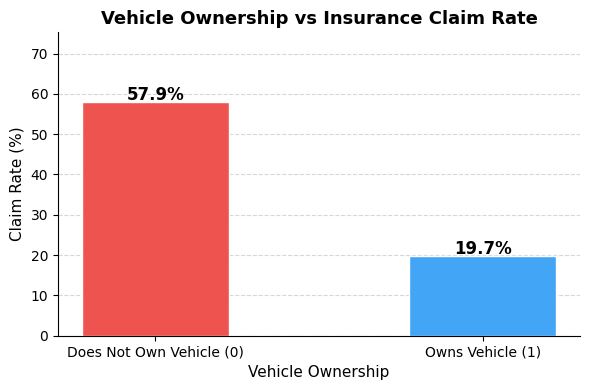

In [49]:
fig, ax = plt.subplots(figsize=(6, 4))

ownership_claims = df.groupby('VEHICLE_OWNERSHIP')['OUTCOME'].mean() * 100

bars = ax.bar(
    ['Does Not Own Vehicle (0)', 'Owns Vehicle (1)'],
    ownership_claims.values,
    color=['#EF5350', '#42A5F5'],
    edgecolor='white',
    width=0.45
)

for bar, val in zip(bars, ownership_claims.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Vehicle Ownership vs Insurance Claim Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('Vehicle Ownership', fontsize=11)
ax.set_ylabel('Claim Rate (%)', fontsize=11)
ax.set_ylim(0, ownership_claims.max() * 1.3)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

sns.despine()
plt.tight_layout()
plt.show()

The plot shows:
  - Customers who do not own their vehicle file insurance claims at a rate of 57.9%, compared to only 19.7% for customers who own their vehicle, nearly 3 times higher. This suggests that non-owners, who may be renting or borrowing a car, feel less personal responsibility for the vehicle, which can lead to riskier driving behavior. Insurance companies should treat vehicle non-ownership as a strong risk indicator when pricing premiums.


## Feature Engineering Using KMeans Clustering

In [50]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_prep)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_prep, labels))

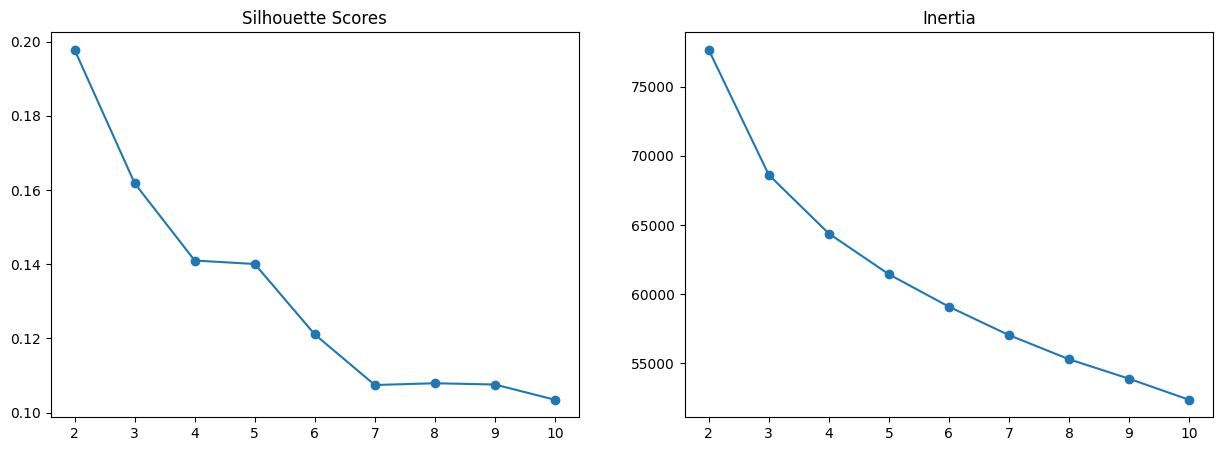

In [51]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
axes[0].plot(k_range, silhouettes, marker='o')
axes[0].set_title('Silhouette Scores')
axes[0].set_xticks(k_range)
axes[1].plot(k_range, inertias, marker='o')
axes[1].set_title('Inertia')
axes[1].set_xticks(k_range);

### Apply KMeans

In [52]:
kmeans = KMeans(n_clusters=3, random_state=42)

train_clusters = kmeans.fit_predict(X_train_prep)
test_clusters = kmeans.predict(X_test_prep)

In [53]:
X_train_kmeans = pd.concat([
    pd.DataFrame(X_train_prep, columns=feature_names),
    pd.DataFrame(train_clusters, columns=['CLUSTER'])
], axis=1)

X_test_kmeans = pd.concat([
    pd.DataFrame(X_test_prep, columns=feature_names),
    pd.DataFrame(test_clusters, columns=['CLUSTER'])
], axis=1)

In [54]:
feature_names_kmeans = list(feature_names) + ['CLUSTER']

print(X_train_kmeans.shape)
print(X_test_kmeans.shape)

(7990, 27)
(1998, 27)


=== Model WITH KMeans Feature ===
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89      5497
         1.0       0.78      0.73      0.75      2493

    accuracy                           0.85      7990
   macro avg       0.83      0.82      0.82      7990
weighted avg       0.85      0.85      0.85      7990



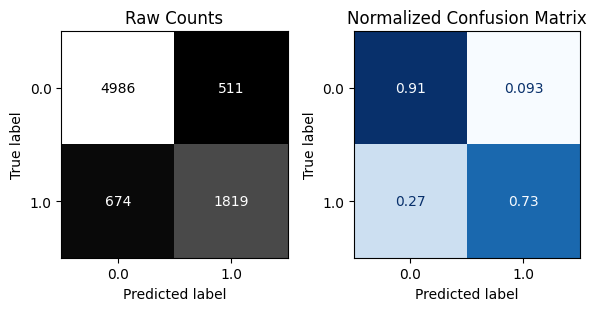


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.90      1367
         1.0       0.79      0.74      0.76       631

    accuracy                           0.86      1998
   macro avg       0.84      0.82      0.83      1998
weighted avg       0.85      0.86      0.85      1998



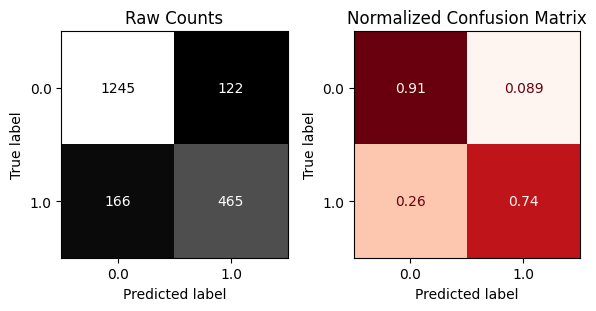

In [55]:
lr_kmeans = LogisticRegression(random_state=42, max_iter=1000)
lr_kmeans.fit(X_train_kmeans, y_train)

print("=== Model WITH KMeans Feature ===")
evaluate_classification(lr_kmeans, X_train_kmeans, y_train,
                                   X_test_kmeans,  y_test)

In [57]:
log_reg_sel = LogisticRegression(C=1e12, max_iter=1000, random_state=42)

selector = SelectFromModel(log_reg_sel)
selector.fit(X_train_kmeans, y_train)

X_train_selected = selector.transform(X_train_kmeans)
X_test_selected  = selector.transform(X_test_kmeans)

above_threshold   = selector.get_support()
selected_features = list(X_train_kmeans.columns[above_threshold])

print(f"Features before: {X_train_kmeans.shape[1]}")
print(f"Features after: {X_train_selected.shape[1]}")

Features before: 27
Features after: 6


=== Final Model (KMeans + SelectFromModel) ===
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.83      0.92      0.87      5497
         1.0       0.77      0.59      0.67      2493

    accuracy                           0.82      7990
   macro avg       0.80      0.76      0.77      7990
weighted avg       0.81      0.82      0.81      7990



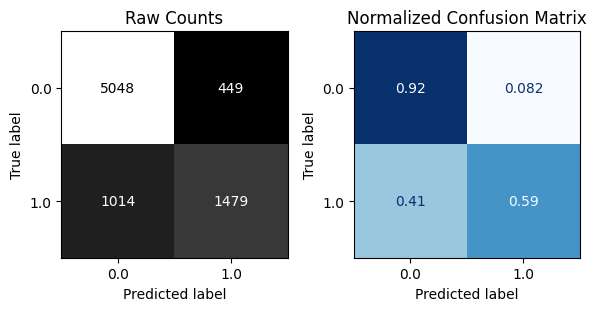


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.84      0.92      0.87      1367
         1.0       0.77      0.61      0.68       631

    accuracy                           0.82      1998
   macro avg       0.80      0.77      0.78      1998
weighted avg       0.82      0.82      0.81      1998



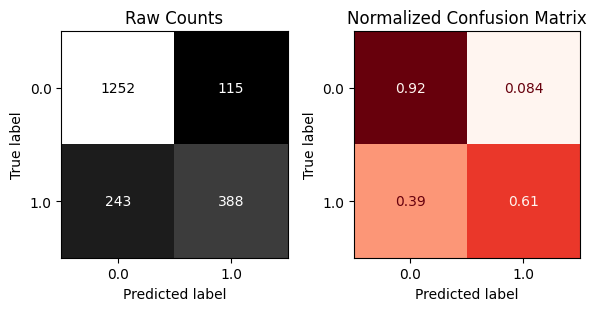

In [58]:
# Final model
lr_final = LogisticRegression(random_state=42, max_iter=1000)
lr_final.fit(X_train_selected, y_train)

print("=== Final Model (KMeans + SelectFromModel) ===")
evaluate_classification(lr_final, X_train_selected, y_train,
                                  X_test_selected,  y_test)

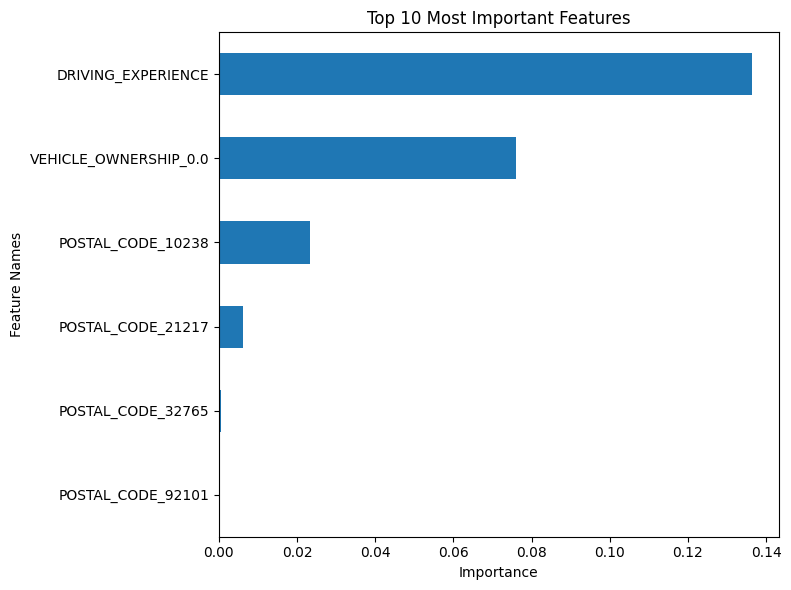

In [59]:
perm_final = permutation_importance(
    lr_final,
    X_test_selected, y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

perm_final_series = pd.Series(
    perm_final.importances_mean,
    index=selected_features
)

plot_importance(perm_final_series, top_n=10)
plt.tight_layout()
plt.show()